In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1

In [2]:
data_dir = '/Users/harryclark/Downloads/COHORT12/medial_lateral_xgboost/'
all_files = glob.glob(os.path.join(data_dir, "*.pkl"))

data = pd.DataFrame()
for file in all_files:
    data = pd.concat([data, pd.read_pickle(file)], ignore_index=True)

# Merge coord_SCs_x from locations into data using mouse, day, and target_cluster_id as keys
data = pd.merge(
    data,
    locations[['mouse', 'day', 'cluster_id', 'coord_SCs_x']],
    how='left',
    left_on=['mouse', 'day', 'target_cluster_id'],
    right_on=['mouse', 'day', 'cluster_id']
 )

             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    pR2_cv  
No. Observations:     770        Method:                REML    
No. Groups:           8          Scale:                 0.0057  
Min. group size:      2          Log-Likelihood:        855.1292
Max. group size:      204        Converged:             Yes     
Mean group size:      96.2                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.317    0.063  4.999 0.000  0.193  0.441
coord_SCs_x           -0.000    0.000 -4.766 0.000 -0.000 -0.000
n_covariate_cells      0.001    0.000 13.425 0.000  0.001  0.001
Group Var              0.003                                    
mouse_day Var          0.000    0.001                           
mouse_day_cluster Var  0.000    0.005  

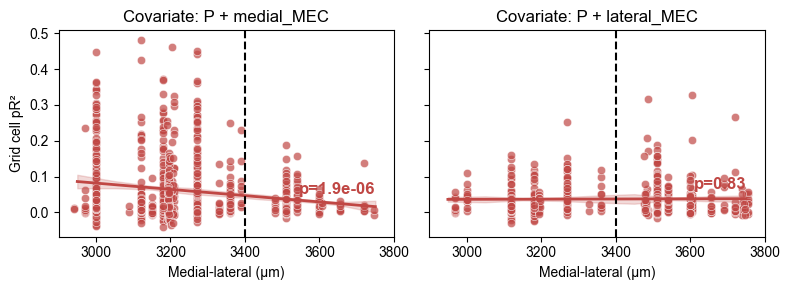

             Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    pR2_cv  
No. Observations:     385        Method:                REML    
No. Groups:           8          Scale:                 0.0025  
Min. group size:      1          Log-Likelihood:        377.5146
Max. group size:      102        Converged:             Yes     
Mean group size:      48.1                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.610    0.103  5.904 0.000  0.408  0.813
coord_SCs_x           -0.000    0.000 -5.298 0.000 -0.000 -0.000
n_covariate_cells      0.001    0.000  1.614 0.107 -0.000  0.001
Group Var              0.001                                    
mouse_day Var          0.002                                    
mouse_day_cluster Var  0.004           

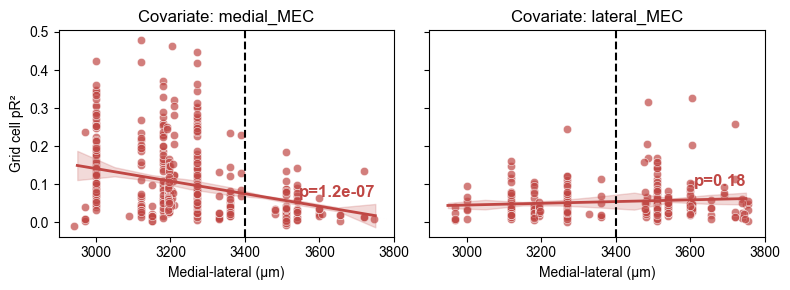

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Define two shades of red
red_palette = ["#c04744", "#c04744"]

for pos_in_cov in [True, False]:
    data_ = data[data['include_position'] == pos_in_cov]

    labels = list(data_['covariate_pos_label'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

    x_bins = np.arange(2900, 3900, 100)
    x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])

    for i, (label, color) in enumerate(zip(labels, red_palette)):
        ax = axes[i]
        subset = data_[data_['covariate_pos_label'] == label].copy()
        sns.scatterplot(
            data=subset,
            x='coord_SCs_x',
            y='pR2_cv',
            color=color,
            alpha=0.7,
            ax=ax
        )

        subset['mouse_day'] = subset['mouse'].astype(str) + '_' + subset['day'].astype(str)
        subset['mouse_day_cluster'] = subset['mouse_day'] + '_' + subset['target_cluster_id'].astype(str)
        model = smf.mixedlm(
            "pR2_cv ~ coord_SCs_x + n_covariate_cells",
            subset,
            groups=subset["mouse"],
            re_formula="1",
            vc_formula={
                "mouse_day": "0 + C(mouse_day)",
                "mouse_day_cluster": "0 + C(mouse_day_cluster)"
            }
        )
        result = model.fit()
        print(result.summary())
        intercept = result.params['Intercept']
        slope = result.params['coord_SCs_x']
        cov_cells_effect = result.params.get('n_covariate_cells', 0)
        mean_cov_cells = subset['n_covariate_cells'].mean()
        y_fit = intercept + slope * x_centers + cov_cells_effect * mean_cov_cells

        # Bin SEM calculation (fixed bin edges)
        sems = []
        for j in range(len(x_bins)-1):
            bin_mask = (subset['coord_SCs_x'] >= x_bins[j]) & (subset['coord_SCs_x'] < x_bins[j+1])
            bin_sem = subset.loc[bin_mask, 'pR2_cv'].sem()
            sems.append(bin_sem if not np.isnan(bin_sem) else 0)
        sems = np.array(sems)

        ax.plot(x_centers, y_fit, color=color, label=f'LMM fit', linewidth=2)
        ax.fill_between(x_centers, y_fit - sems, y_fit + sems, color=color, alpha=0.2)

        # Annotate p-value at the rightmost part of the fit line
        pval = result.pvalues.get('coord_SCs_x', None)
        if pval is not None:
            y_annot = y_fit[-1] + sems[-1] + 0.01
            ax.text(x_centers[-1], y_annot, f'p={pval:.2g}', color=color, fontsize=12, ha='right', va='bottom', fontweight='bold')

        ax.set_xlim(2900, 3800)
        ax.axvline(3400, linestyle='dashed', color='black')
        ax.set_xlabel('Medial-lateral (μm)')
        if i == 0:
            ax.set_ylabel('Grid cell pR²')
        fig.tight_layout()

        if pos_in_cov:
            ax.set_title(f'Covariate: P + {label}')
            plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/absolute_pr2_grid_cells_split_pos.pdf')
        else:
            ax.set_title(f'Covariate: {label}')
            plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/absolute_pr2_grid_cells_split_no_pos.pdf')
    plt.show()


LMM summary for include_position=True, covariate=medial_MEC:
              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    pR2_cv  
No. Observations:      770        Method:                REML    
No. Groups:            8          Scale:                 0.0056  
Min. group size:       2          Log-Likelihood:        861.3500
Max. group size:       204        Converged:             No      
Mean group size:       96.2                                      
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.040    0.020  1.977 0.048  0.000  0.079
C(ml_label)[T.lateral] -0.036    0.008 -4.381 0.000 -0.053 -0.020
n_covariate_cells       0.001    0.000 13.214 0.000  0.001  0.001
Group Var               0.003                                    
mouse_day Var           0.00

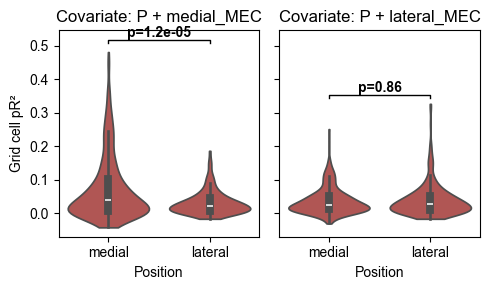


LMM summary for include_position=False, covariate=medial_MEC:
              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    pR2_cv  
No. Observations:      385        Method:                REML    
No. Groups:            8          Scale:                 0.0025  
Min. group size:       1          Log-Likelihood:        387.6325
Max. group size:       102        Converged:             Yes     
Mean group size:       48.1                                      
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.111    0.022  5.048 0.000  0.068  0.155
C(ml_label)[T.lateral] -0.079    0.013 -6.030 0.000 -0.105 -0.054
n_covariate_cells       0.000    0.000  0.274 0.784 -0.001  0.001
Group Var               0.001                                    
mouse_day Var           0.0

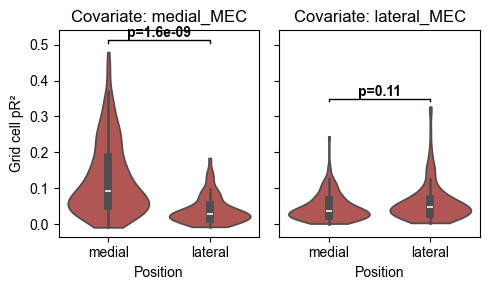

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Define two shades of red for the two covariate panels
red_palette = ["#c04744", "#c04744"]

# Medial–lateral boundary
boundary = 3400

for pos_in_cov in [True, False]:
    data_ = data[data['include_position'] == pos_in_cov].copy()

    # Use the same covariate labels as before
    labels = list(data_['covariate_pos_label'].unique())

    # Create 1×2 subplots (one per covariate label)
    fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)

    for i, (label, color) in enumerate(zip(labels, red_palette)):
        ax = axes[i]

        # Subset for this covariate label
        subset = data_[data_['covariate_pos_label'] == label].copy()

        # Drop obvious NaNs
        subset = subset.dropna(subset=['pR2_cv', 'coord_SCs_x'])

        # Define medial vs lateral using the 3400 µm boundary
        subset['ml_label'] = np.where(
            subset['coord_SCs_x'] < boundary,
            'medial',
            'lateral'
        )

        # Optional: ensure categorical order
        subset['ml_label'] = pd.Categorical(
            subset['ml_label'],
            categories=['medial', 'lateral'],
            ordered=True
        )

        # Violin plot of Grid cell pR² for medial vs lateral
        sns.violinplot(
            data=subset,
            x='ml_label',
            y='pR2_cv',
            order=['medial', 'lateral'],
            palette={'medial': color, 'lateral': color},
            cut=0,
            inner='box',
            ax=ax
        )

        # ----- Mixed-effects model for medial vs lateral + p-value annotation -----
        # Build hierarchical grouping variables
        subset_lmm = subset.copy()
        subset_lmm['mouse_day'] = (
            subset_lmm['mouse'].astype(str) + '_' + subset_lmm['day'].astype(str)
        )
        subset_lmm['mouse_day_cluster'] = (
            subset_lmm['mouse_day'] + '_' + subset_lmm['target_cluster_id'].astype(str)
        )

        # Mixed model: effect of ml_label, controlling for n_covariate_cells
        model = smf.mixedlm(
            "pR2_cv ~ C(ml_label) + n_covariate_cells",
            subset_lmm,
            groups=subset_lmm["mouse"],
            re_formula="1",
            vc_formula={
                "mouse_day": "0 + C(mouse_day)",
                "mouse_day_cluster": "0 + C(mouse_day_cluster)",
            },
        )
        result = model.fit()
        print(f"\nLMM summary for include_position={pos_in_cov}, covariate={label}:")
        print(result.summary())

        # Extract p-value for medial vs lateral (C(ml_label) term)
        effect_terms = [name for name in result.params.index if "C(ml_label)" in name]
        if len(effect_terms) > 0:
            term = effect_terms[0]
            pval = result.pvalues[term]

            # Draw a bracket between medial (x=0) and lateral (x=1)
            x1, x2 = 0, 1
            y_min = subset['pR2_cv'].min()
            y_max = subset['pR2_cv'].max()
            span = y_max - y_min if y_max > y_min else 1.0

            y = y_max + 0.05 * span
            h = 0.02 * span

            ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y],
                    color='black', linewidth=1)

            ax.text(
                (x1 + x2) / 2,
                y + h,
                f"p={pval:.2g}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )
        # -------------------------------------------------------------------------

        ax.set_xlabel('Position')
        if i == 0:
            ax.set_ylabel('Grid cell pR²')
        else:
            ax.set_ylabel('')

        # Panel titles reflect covariate type and whether position is included
        if pos_in_cov:
            ax.set_title(f'Covariate: P + {label}')
        else:
            ax.set_title(f'Covariate: {label}')

    fig.tight_layout()

    # Save a separate figure for each include_position condition
    if pos_in_cov:
        plt.savefig(
            '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            'figure_3_xgboost/absolute_pr2_grid_cells_split_pos_violin.pdf',
            dpi=500
        )
    else:
        plt.savefig(
            '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
            'figure_3_xgboost/absolute_pr2_grid_cells_split_no_pos_violin.pdf',
            dpi=500
        )

    plt.show()


LMM summary for pure position covariate:
            Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   pR2_cv   
No. Observations:    633       Method:               REML     
No. Groups:          8         Scale:                0.0006   
Min. group size:     1         Log-Likelihood:       1387.6494
Max. group size:     150       Converged:            Yes      
Mean group size:     79.1                                     
--------------------------------------------------------------
                      Coef. Std.Err.   z   P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept             0.016    0.006 2.714 0.007  0.004  0.027
C(ml_label)[T.medial] 0.003    0.003 1.092 0.275 -0.002  0.008
Group Var             0.000    0.005                          
mouse_day Var         0.000    0.001                          


LMM summary for include_position=True, covariate=medial_MEC:
              Mixed Linear

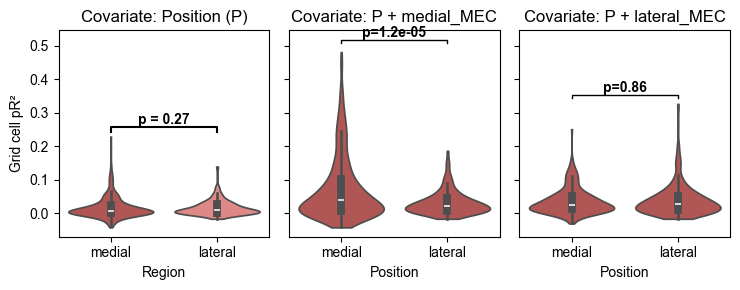


LMM summary for include_position=False, covariate=medial_MEC:
              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    pR2_cv  
No. Observations:      385        Method:                REML    
No. Groups:            8          Scale:                 0.0025  
Min. group size:       1          Log-Likelihood:        387.6325
Max. group size:       102        Converged:             Yes     
Mean group size:       48.1                                      
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.111    0.022  5.048 0.000  0.068  0.155
C(ml_label)[T.lateral] -0.079    0.013 -6.030 0.000 -0.105 -0.054
n_covariate_cells       0.000    0.000  0.274 0.784 -0.001  0.001
Group Var               0.001                                    
mouse_day Var           0.0

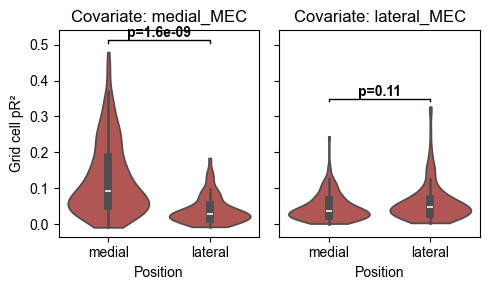

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Define two shades of red for the two covariate panels
red_palette = ["#c04744", "#c04744"]

# Medial–lateral boundary
boundary = 3400

for pos_in_cov in [True, False]:
    data_ = data[data['include_position'] == pos_in_cov].copy()

    if pos_in_cov:
        # ----- LEFT PANEL: position-only covariate -----
        subset_pos = data_.copy()
        # Keep only rows with pure position covariate (no extra covariate cells)
        subset_pos = subset_pos[subset_pos['n_covariate_cells'] == 0].copy()

        # Drop obvious NaNs
        subset_pos = subset_pos.dropna(subset=["coord_SCs_x", "pR2_cv"])

        # Medial / lateral label based on SC coordinate
        subset_pos["ml_label"] = np.where(
            subset_pos["coord_SCs_x"] < boundary, "medial", "lateral"
        )

        # Add mouse_day column for hierarchical grouping (day nested within mouse)
        subset_pos["mouse_day"] = (
            subset_pos["mouse"].astype(str) + "_" + subset_pos["day"].astype(str)
        )

        # Fit LMM: pR2_cv ~ ml_label, with random intercepts for mouse and day (nested)
        model_pos = smf.mixedlm(
            "pR2_cv ~ C(ml_label)",
            subset_pos,
            groups=subset_pos["mouse"],
            re_formula="1",
            vc_formula={"mouse_day": "0 + C(mouse_day)"},
        )
        result_pos = model_pos.fit()
        print("\nLMM summary for pure position covariate:")
        print(result_pos.summary())

        # Extract p-value for medial vs lateral effect
        effect_param_pos = [
            name for name in result_pos.params.index if "ml_label" in name
        ][0]
        pval_pos = result_pos.pvalues[effect_param_pos]

        # ----- MIDDLE/RIGHT PANELS: P + extra covariates -----
        # Use only covariate labels with extra cells (exclude pure position: n_covariate_cells == 0)
        labels = list(
            data_[data_["n_covariate_cells"] > 0]["covariate_pos_label"].unique()
        )

        # Create 1×(1 + n_labels) subplots: left = position-only, others = P + covariates
        n_cov_panels = len(labels)
        fig, axes = plt.subplots(
            1, 1 + n_cov_panels, figsize=(2.5 * (1 + n_cov_panels), 3), sharey=True
        )

        # Make sure axes is indexable
        if n_cov_panels == 1:
            # axes is a 1D array here; keep as-is
            pass

        # Left axis: position-only
        ax_pos = axes[0]

        # Violin plot for pure position model
        sns.violinplot(
            data=subset_pos,
            x="ml_label",
            y="pR2_cv",
            order=["medial", "lateral"],
            palette={"medial": "#c04744", "lateral": "#ec7b79"},
            inner="box",
            cut=0,
            ax=ax_pos,
        )
        ax_pos.set_xlabel("Region")
        ax_pos.set_ylabel("Grid cell pR²")
        ax_pos.set_title("Covariate: Position (P)")

        # Bracket + p-value for pure position
        x1, x2 = 0, 1
        ymin = subset_pos["pR2_cv"].min()
        ymax = subset_pos["pR2_cv"].max()
        dy = ymax - ymin if ymax > ymin else 1.0
        h = 0.05 * dy
        line_y = ymax + h
        text_y = line_y + h

        ax_pos.plot(
            [x1, x1, x2, x2],
            [line_y, line_y + h, line_y + h, line_y],
            color="black",
            linewidth=1.5,
        )
        ax_pos.text(
            (x1 + x2) / 2,
            text_y,
            f"p = {pval_pos:.2g}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

        # Axes for the P + covariate panels
        cov_axes = axes[1:]
    else:
        # No position in covariate: just 2 panels for the two covariate sets
        labels = list(data_["covariate_pos_label"].unique())
        fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)
        cov_axes = axes  # both axes are for covariate panels

    # ----- Covariate panels (with or without position) -----
    for i, (label, color) in enumerate(zip(labels, red_palette)):
        ax = cov_axes[i]

        # Subset for this covariate label
        subset = data_[data_["covariate_pos_label"] == label].copy()

        # Drop obvious NaNs
        subset = subset.dropna(subset=["pR2_cv", "coord_SCs_x"])

        # Define medial vs lateral using the 3400 µm boundary
        subset["ml_label"] = np.where(
            subset["coord_SCs_x"] < boundary, "medial", "lateral"
        )

        # Optional: ensure categorical order
        subset["ml_label"] = pd.Categorical(
            subset["ml_label"], categories=["medial", "lateral"], ordered=True
        )

        # Violin plot of Grid cell pR² for medial vs lateral
        sns.violinplot(
            data=subset,
            x="ml_label",
            y="pR2_cv",
            order=["medial", "lateral"],
            palette={"medial": color, "lateral": color},
            cut=0,
            inner="box",
            ax=ax,
        )

        # Mixed-effects model for medial vs lateral + p-value annotation
        subset_lmm = subset.copy()
        subset_lmm["mouse_day"] = (
            subset_lmm["mouse"].astype(str) + "_" + subset_lmm["day"].astype(str)
        )
        subset_lmm["mouse_day_cluster"] = (
            subset_lmm["mouse_day"]
            + "_"
            + subset_lmm["target_cluster_id"].astype(str)
        )

        model = smf.mixedlm(
            "pR2_cv ~ C(ml_label) + n_covariate_cells",
            subset_lmm,
            groups=subset_lmm["mouse"],
            re_formula="1",
            vc_formula={
                "mouse_day": "0 + C(mouse_day)",
                "mouse_day_cluster": "0 + C(mouse_day_cluster)",
            },
        )
        result = model.fit()
        print(f"\nLMM summary for include_position={pos_in_cov}, covariate={label}:")
        print(result.summary())

        effect_terms = [name for name in result.params.index if "C(ml_label)" in name]
        if len(effect_terms) > 0:
            term = effect_terms[0]
            pval = result.pvalues[term]

            # Draw a bracket between medial (x=0) and lateral (x=1)
            x1, x2 = 0, 1
            y_min = subset["pR2_cv"].min()
            y_max = subset["pR2_cv"].max()
            span = y_max - y_min if y_max > y_min else 1.0

            y = y_max + 0.05 * span
            h = 0.02 * span

            ax.plot(
                [x1, x1, x2, x2],
                [y, y + h, y + h, y],
                color="black",
                linewidth=1,
            )

            ax.text(
                (x1 + x2) / 2,
                y + h,
                f"p={pval:.2g}",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )

        ax.set_xlabel("Position")
        # Y-label only on the left-most panel in each figure
        if pos_in_cov:
            # Left-most is position-only; covariate panels have no y-label
            ax.set_ylabel("")
        else:
            ax.set_ylabel("Grid cell pR²" if i == 0 else "")

        # Panel titles
        if pos_in_cov:
            ax.set_title(f"Covariate: P + {label}")
        else:
            ax.set_title(f"Covariate: {label}")

    fig.tight_layout()

    # Save a separate figure for each include_position condition
    if pos_in_cov:
        plt.savefig(
            "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/"
            "figure_3_xgboost/absolute_pr2_grid_cells_split_pos_violin_with_P.pdf",
            dpi=500,
        )
    else:
        plt.savefig(
            "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/"
            "figure_3_xgboost/absolute_pr2_grid_cells_split_no_pos_violin.pdf",
            dpi=500,
        )

    plt.show()